In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set()

In [2]:
data = loadmat('dataset.mat')

In [3]:
X = data['X']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

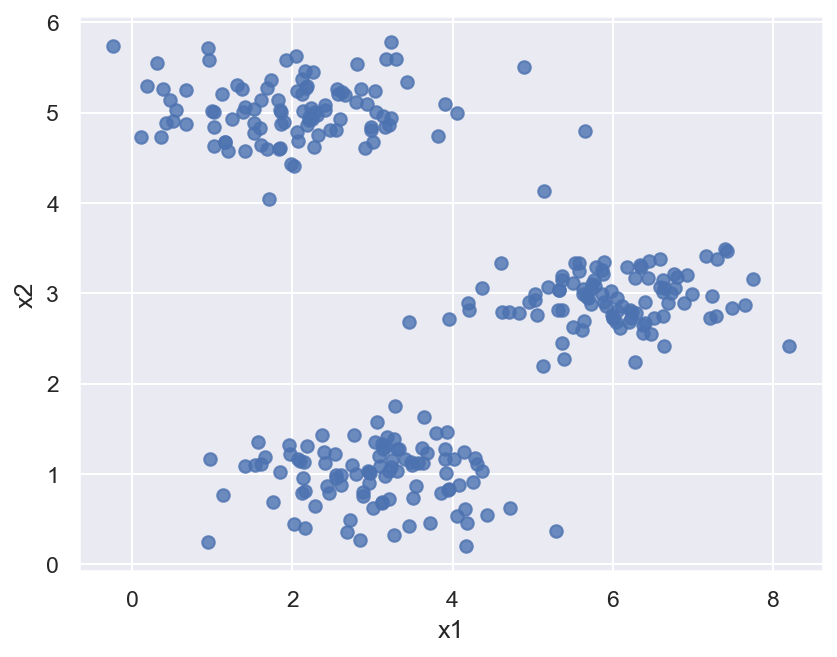

In [4]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [5]:
# 预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
# 根据数据分布以及作业要求，先设置默认k=3（可根据k-cost曲线调整）
k = 3

In [6]:
# 随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（元素为ndarray的list)
    注意：需保证随机取的样本不重复
    """
    n = X.shape[0]
    # 随机选择不重复的索引
    idx = random.sample(range(n), k)
    centers = [X[i].copy() for i in idx]
    return centers

In [7]:
# 向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray) 或 多个样本(ndarray形状(n, d)), v2:中心(ndarray) 或 centers(ndarray形状(k, d))
    输出：distance: 欧氏距离 (float 或 ndarray)
    """
    # 使用 numpy 广播计算欧氏距离
    v1 = np.array(v1)
    v2 = np.array(v2)
    diff = v1 - v2
    return np.sqrt((diff ** 2).sum(axis=-1))

In [8]:
# 将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（列表或ndarray）
    输出：assignment: 字典，key为簇标号，value为元素是ndarray的list
    返回每个样本所属的簇索引数组也很有用
    """
    X = np.array(X)
    centers_arr = np.array(centers)
    # 计算每个样本到每个中心的距离，形状 (n_samples, k)
    dists = np.sqrt(((X[:, None, :] - centers_arr[None, :, :]) ** 2).sum(axis=2))
    labels = np.argmin(dists, axis=1)
    assignment = {i: [] for i in range(len(centers))}
    for idx, label in enumerate(labels):
        assignment[label].append(X[idx])
    # 将每个列表转为 ndarray 方便后续计算
    for k in assignment:
        assignment[k] = np.array(assignment[k]) if len(assignment[k])>0 else np.empty((0, X.shape[1]))
    return assignment, labels

In [9]:
# 代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：assignment: 字典或labels数组, centers: 中心列表或ndarray
    输出：cost: 代价函数值 (float)
    """
    total = 0.0
    count = 0
    for i, center in enumerate(centers):
        pts = assignment.get(i, np.empty((0, center.shape[0])))
        if pts.size == 0:
            continue
        # pts 形状 (m, d)
        d = np.sqrt(((pts - center) ** 2).sum(axis=1))
        total += d.sum()
        count += pts.shape[0]
    return total / count if count>0 else 0.0

In [10]:
# 更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(字典：key为簇标号、value为ndarray), centers：当前中心（元素为ndarray的list)
    输出：new_centers: 更新的中心集（元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    """
    new_centers = []
    stop = 1
    for i in range(len(centers)):
        pts = assignment.get(i, np.empty((0, centers[0].shape[0])))
        if pts.size == 0:
            # 若某簇没有样本，保持原中心不变
            new_centers.append(centers[i].copy())
            continue
        mean = pts.mean(axis=0)
        new_centers.append(mean)
        if not np.allclose(mean, centers[i]):
            stop = 0
    return new_centers, stop

In [11]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [12]:
# kmeans 及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X: 数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot: 是否可视化（True/False)
    输出：assignment(字典：key为簇标号、value为ndarray的list), cost: 最终的代价函数值(float)
    """
    X = np.array(X)
    centers = init_centers(X, k)
    cost = None
    for epoch in range(1, max_epoch+1):
        assignment, labels = cluster_assignment(X, centers)
        new_centers, stop = center_update(assignment, centers)
        centers = new_centers
        cost = cost_function(assignment, centers)
        if plot:
            plot_clustering(assignment, centers, epoch)
        if stop == 1:
            break
    return assignment, cost

In [13]:
max_epoch = 200 

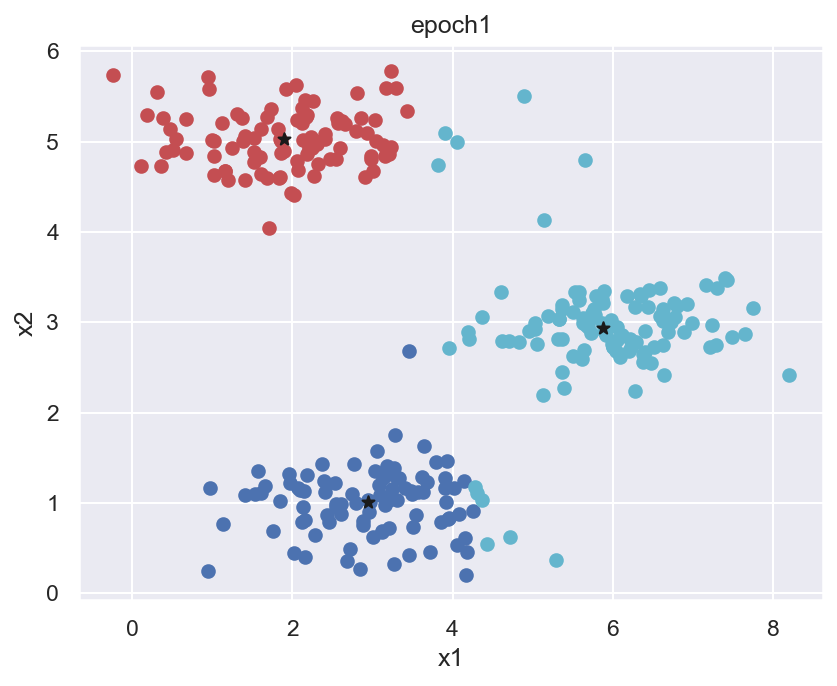

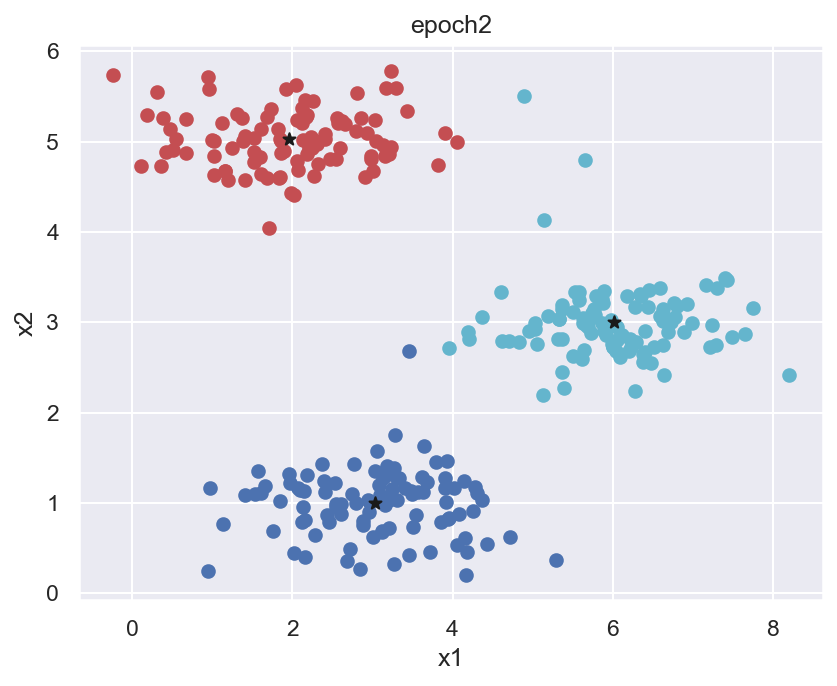

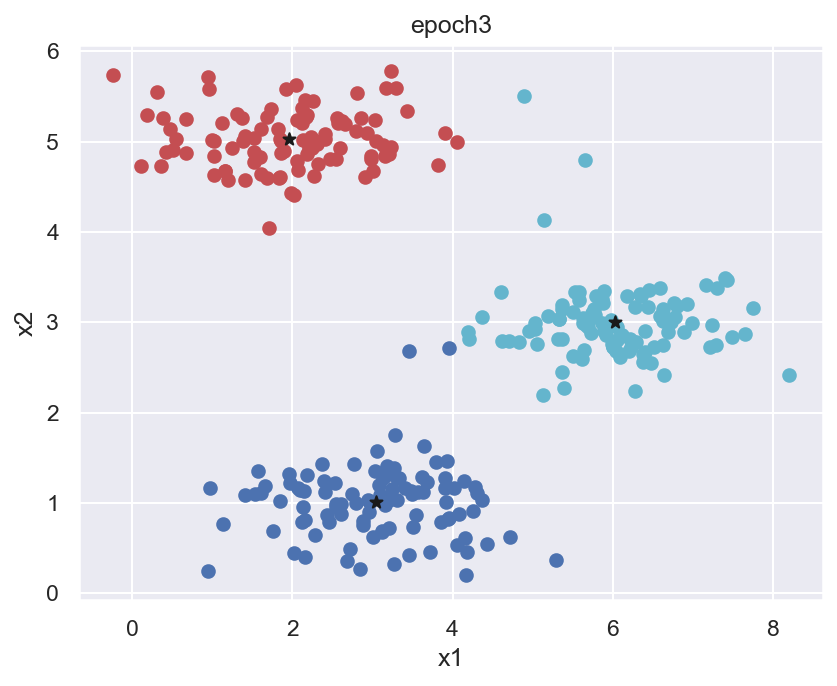

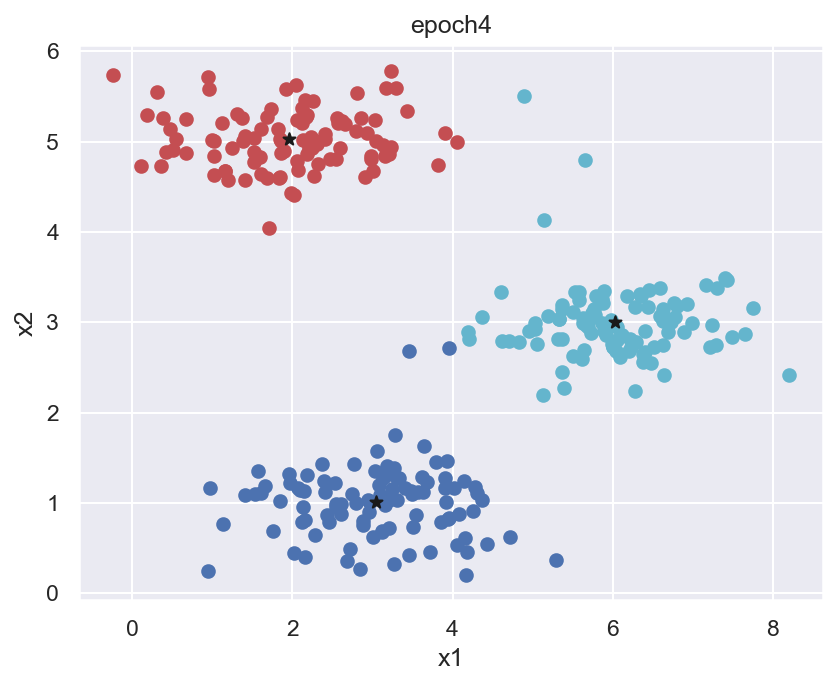

In [14]:
assignment, _ = kmeans(X, k, max_epoch)

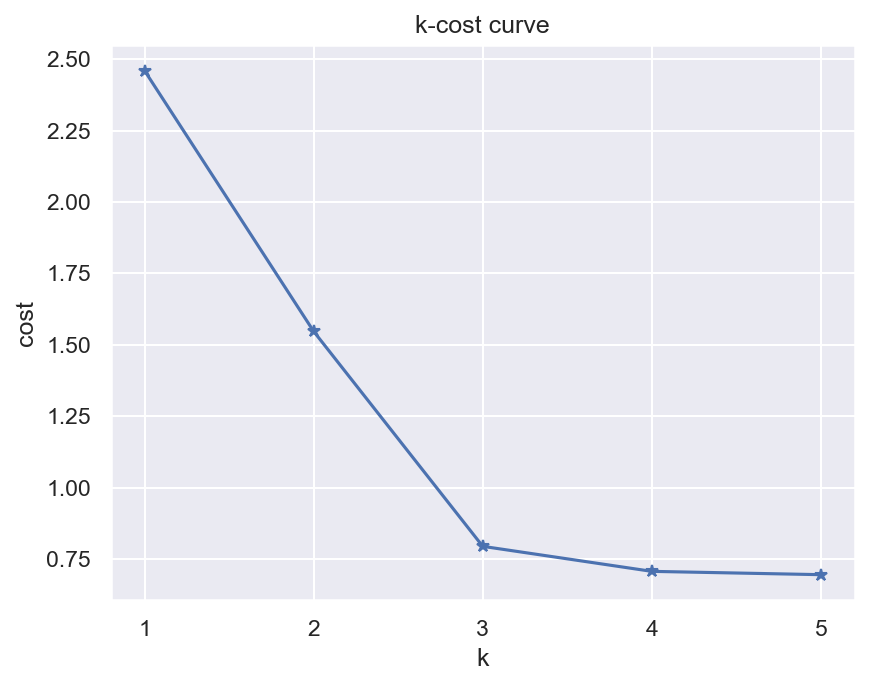

In [15]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()